# Trophoblast plotting

In [1]:
source(here::here("settings.R"))
ArchRProject <- loadArchRProject(file.path(io$basedir, 'ArchR/Trophoblast'))
library(viridis)

# I/O
io$plot.trophoblast = file.path(io$basedir, 'ArchR/Trophoblast/Plots')
dir.create(io$plot.trophoblast, showWarnings = FALSE)

Setting default number of Parallel threads to 1.

Setting addArchRVerbose = FALSE

Successfully loaded ArchRProject!


                                                   / |
                                                 /    \
            .                                  /      |.
            \\\                              /        |.
              \\\                          /           `|.
                \\\                      /              |.
                  \                    /                |\
                  \\#####\           /                  ||
                ==###########>      /                   ||
                 \\##==......\    /                     ||
            ______ =       =|__ /__                     ||      \\\
        ,--' ,----`-,__ ___/'  --,-`-===================##========>
       \               '        ##_______ _____ ,--,__,=##,__   ///
        ,    __==    ___,-,__,--'#'  ==='      `-'    | ##,-/
        -,____,---'       \\####\\__

In [2]:
minmax = function(x){
    (x - min(x))/(max(x) - min(x))
}

In [3]:
celltype_levels = c('Trophoblast',                  
                  'Cytotrophoblast',
                  'Syncytiotrophoblast Progenitors',
                  'Syncytiotrophoblast',
                  'Amnion 1',
                  'Amnion 1/Amnion 2',
                  'Amnion 1/Amnion 2/Amnion 3',
                  'Amnion 2',
                  'Amnion 2/Amnion 3',
                  'Amnion 3/Trophoblast',
                  'Amnion 3')

Cluster_levels = c('C3', 
                   'C7',
                   'C9', 
                   'C8', 
                   'C2', 
                   'C1', 
                   'C5', 
                   'C4', 
                   'C6')

# Plot known markers - GeneScoreMatrix

In [6]:
meta = as.data.table(ArchRProject@cellColData[,c('cell', 'Clusters')])

In [7]:
markers = fread(file.path(io$basedir,'Tropho_amnion_markers.csv'), header=F) %>% setnames(c('celltype', 'marker'))

In [8]:
# Identify markers that span multiple celltypes
markers = rbindlist(lapply(unique(markers$marker), function(gene){
        tmp = markers[marker==gene]
        markers_ct = data.table(celltype=paste(tmp$celltype, collapse='/'), marker=gene)
        return(markers_ct)
    }))

In [9]:
markers = markers %>% .[,celltype:=factor(celltype, levels = celltype_levels)] %>% .[order(-celltype)]

In [10]:
# Get GeneScoreMatrix
matrix = 'GeneScoreMatrix'

genescores = getMatrixFromProject(
    ArchRProj = ArchRProject,
    useMatrix = matrix)
names = rowData(genescores)$name
genescores = assays(genescores)[[matrix]]
rownames(genescores) = names

markers_matrix = genescores[rownames(genescores) %in% markers$marker,]

In [9]:
## Impute values 
# Add imputation 
ArchRProject <- addImputeWeights(ArchRProject, 
                                reducedDims = 'PeakMatrix_tropho')
# Run imputation
markers_matrix.imputed = imputeMatrix(mat = as.matrix(markers_matrix), 
                             imputeWeights = getImputeWeights(ArchRProject))

Warning message in sprintf("Completed Getting Magic Weights!", round(object.size(weightList)/10^9, :
“one argument not used by format 'Completed Getting Magic Weights!'”
Getting ImputeWeights



In [10]:
summary(colnames(markers_matrix.imputed) == rownames(ArchRProject))

   Mode   FALSE    TRUE 
logical    2502     259 

In [11]:
markers_matrix.imputed = markers_matrix.imputed[,match(rownames(ArchRProject), colnames(markers_matrix.imputed))]

In [12]:
summary(colnames(markers_matrix.imputed) == rownames(ArchRProject))

   Mode    TRUE 
logical    2761 

In [13]:
library(SingleCellExperiment)
library(scuttle)

BPPARAM <- BiocParallel::bpparam()
BPPARAM$workers = 16

rownames(markers_matrix.imputed) = as.character(rownames(markers_matrix.imputed))

# minmax imputed count matrix
markers_matrix.imputed.minmax = apply(markers_matrix.imputed, 1, minmax) %>% t()

sce <- SingleCellExperiment(list(counts=markers_matrix.imputed.minmax))

colData(sce) = ArchRProject@cellColData
sce_pseudobulk <- aggregateAcrossCells(sce, id=sce$Clusters, statistics = 'mean', BPPARAM = BPPARAM)

In [14]:
counts_pseudobulk = counts(sce_pseudobulk)

In [15]:
counts.mod = counts_pseudobulk

In [16]:
plot = as.data.table(t(counts.mod), keep.rownames=T) %>% 
        setnames('rn', 'Clusters') %>%
        melt(id.vars =  'Clusters') %>%
        unique(by=c('variable', 'value', 'Clusters')) %>% 
        merge(.,markers,  by.x='variable', by.y='marker') %>% 
        setnames('variable', 'gene')

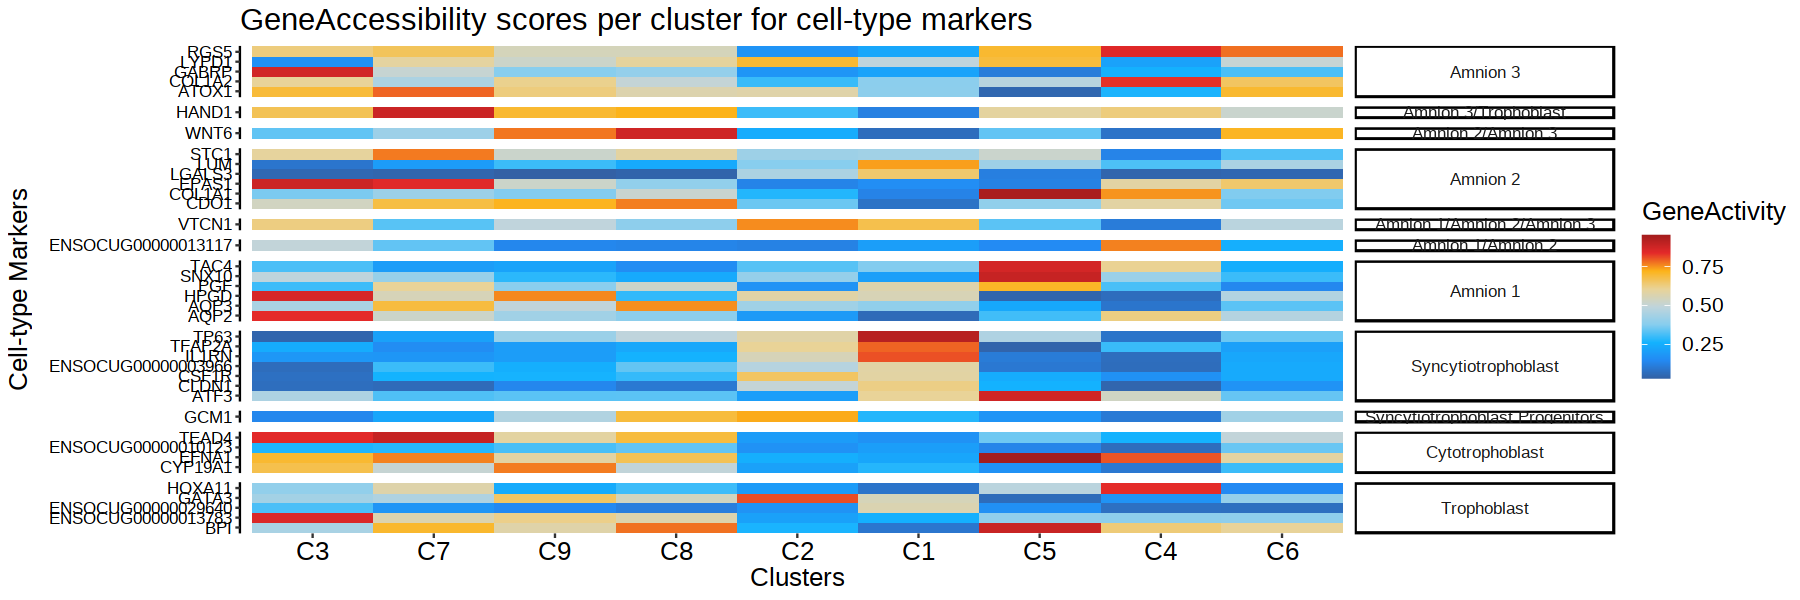

In [17]:
ggplot(plot, aes(factor(Clusters, levels = Cluster_levels), gene, fill=value)) +  # factor(gene, levels=unique(markers$marker))
        geom_tile() + 
        facet_grid(factor(celltype, levels = rev(celltype_levels))~., scales ='free_y', space = "free") + 
        ylab('Cell-type Markers') +
        xlab('Clusters') + 
        ggtitle('GeneAccessibility scores per cluster for cell-type markers') + 
        scale_fill_gradientn(colors = paletteContinuous(), name='GeneActivity') + 
        theme_classic() + theme(text = element_text(size = 15, colour='black'), 
                                axis.text.y = element_text(hjust=1, size = 10, colour='black'),
                                axis.text.x = element_text(size = 15, colour='black'),
                                axis.line.x = element_blank(),
                               strip.text.y = element_text(angle = 0, size=10))

#### Mean per celltype

In [18]:
markers = fread(file.path(io$basedir,'Tropho_amnion_markers.csv'), header=F) %>% setnames(c('celltype', 'marker'))
markers = markers %>% .[,celltype:=factor(celltype, levels = celltype_levels)] %>% .[order(-celltype)]

In [30]:
# celltype mean
plot = mclapply(unique(markers$celltype), function(x){
    markers.tmp = intersect(markers[celltype==x, marker], rownames(counts.mod))
    tmp = counts.mod[markers.tmp,]
    if(length(markers.tmp)>1){
        tmp = colMeans(tmp)
    }
    tmp = data.table(celltype = x, Clusters = names(tmp), celltype_mean = tmp)
    return(tmp)
}, mc.cores=16) %>% rbindlist()

In [31]:
plot$broad = ifelse(plot$celltype %in% c('Trophoblast',                  
                  'Cytotrophoblast',
                  'Syncytiotrophoblast Progenitors',
                  'Syncytiotrophoblast'), 'Tropho', 'Amnion')

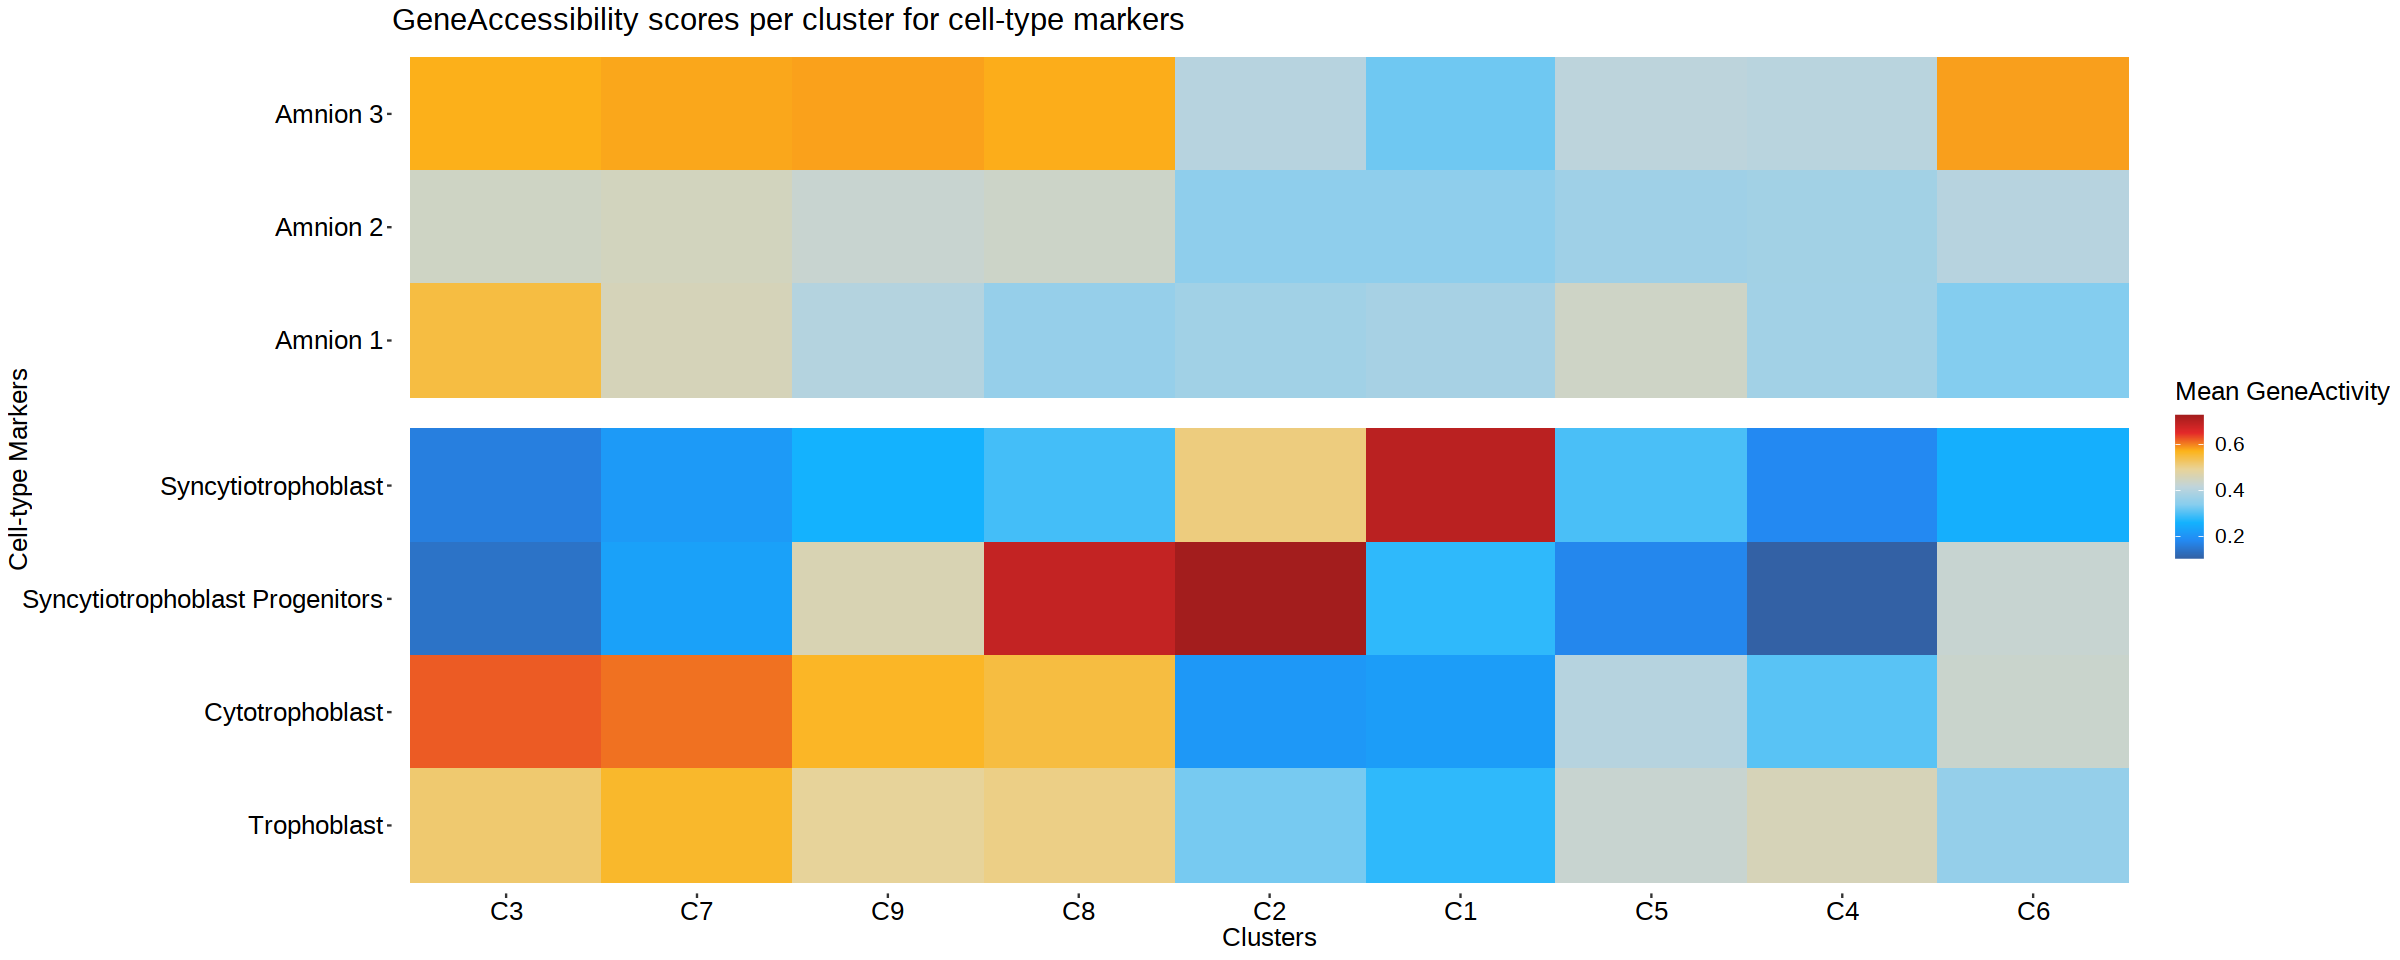

In [32]:
ggplot(plot, aes(factor(Clusters, levels = Cluster_levels), factor(celltype, levels = celltype_levels), fill=celltype_mean)) + 
        geom_tile() + 
        facet_grid(rows=vars(broad), scales ='free_y', space = "free") + 
        ylab('Cell-type Markers') +
        xlab('Clusters') + 
        ggtitle('GeneAccessibility scores per cluster for cell-type markers') + 
        scale_fill_gradientn(colors = paletteContinuous(), name='Mean GeneActivity') + 
        theme_classic() + theme(text = element_text(size = 15, colour='black'), 
                                axis.text.y = element_text(hjust=1, size = 15, colour='black'),
                                axis.text.x = element_text(size = 15, colour='black'),
                                axis.line.x = element_blank(),
                                axis.line.y = element_blank(),
                               strip.text.y = element_blank(),
                               strip.background = element_blank())

#### All celltype markers

#### Get RNA markers

In [818]:
# Load RNA
io$RNA_in <- file.path(io$basedir,"RNA/RangedSummarizedExperiment.rds")
sceRNA = readRDS(io$RNA_in)

In [819]:
sceRNA

class: RangedSummarizedExperiment 
dim: 20845 146133 
metadata(0):
assays(1): counts
rownames(20845): WDR31 RNF183 ... ENSOCUG00000014718 ENSOCUG00000019471
rowData names(2): gene_id symbol
colnames(146133): cell_1 cell_2 ... cell_172994 cell_172995
colData names(25): cell cell ... somite_count stage

In [822]:
sceRNA$celltype = ifelse(sceRNA$celltype == 'Syncytiotrophoblast progenitors', 'Syncytiotrophoblast Progenitors', sceRNA$celltype)

In [825]:
sceRNA = sceRNA[,sceRNA$celltype %in% c('Trophoblast','Cytotrophoblast','Syncytiotrophoblast Progenitors','Syncytiotrophoblast','Amnion 1','Amnion 2','Amnion 3')]

In [827]:
# RNA marker gene detection
summed <- aggregateAcrossCells(sceRNA, 
                               id=colData(sceRNA)[,c("celltype", "sample")],
                               BPPARAM = BPPARAM)
summed

class: RangedSummarizedExperiment 
dim: 20845 112 
metadata(0):
assays(1): counts
rownames(20845): WDR31 RNF183 ... ENSOCUG00000014718 ENSOCUG00000019471
rowData names(2): gene_id symbol
colnames: NULL
colData names(28): cell cell.1 ... sample ncells

In [828]:
library(scran)

In [829]:
RNA_all_markers = mclapply(unique(summed$celltype), function(x){
    summed$test = ifelse(summed$celltype == x, 'group', 'background')

    between.res <- pseudoBulkDGE(summed,
        label=rep("dummy", ncol(summed)),
        design=~factor(sample) + test,
        coef="testgroup")[[1]]

    RNA_markers = as.data.table(between.res, keep.rownames=T) %>% 
        setnames('rn', 'gene') %>%
        .[,celltype:=x] %>%
        .[logFC>1 & FDR<0.05] %>% 
        .[order(-logFC)] 

    return(RNA_markers)
}, mc.cores=16) %>% rbindlist(.)

In [841]:
fwrite(RNA_all_markers, '/rds/project/rds-SDzz0CATGms/users/bt392/04_rabbit_scATAC/RNA/Trophoblast_celltype_markers.txt.gz')

#### plot RNA marker accessibility

In [20]:
markers_RNA = fread('/rds/project/rds-SDzz0CATGms/users/bt392/04_rabbit_scATAC/RNA/Trophoblast_celltype_markers.txt.gz') %>% setnames('gene', 'marker') %>%
    .[order(-logFC)] %>%
    .[logFC>1,] %>% 
    .[,head(.SD, 15), by='celltype'] 

In [833]:
## Run on full GeneScoreMatrix instead of only marker genes
# Run imputation
genescores.imputed = imputeMatrix(mat = as.matrix(genescores), 
                             imputeWeights = getImputeWeights(ArchRProject))

Getting ImputeWeights



In [834]:
genescores.imputed = genescores.imputed[,match(rownames(ArchRProject), colnames(genescores.imputed))]

In [835]:
summary(colnames(genescores.imputed) == rownames(ArchRProject))

   Mode    TRUE 
logical    2761 

In [865]:
summary(colnames(genescores) == rownames(ArchRProject))

   Mode   FALSE    TRUE 
logical    2502     259 

In [866]:
rownames(genescores.imputed) = as.character(rownames(genescores.imputed))

# minmax imputed count matrix
genescores.imputed.minmax = apply(genescores.imputed, 1, minmax) %>% t()

#sce <- SingleCellExperiment(list(counts=genescores.imputed.minmax))
#sce <- SingleCellExperiment(list(counts=genescores.imputed))

genescores = genescores.imputed[,match(rownames(ArchRProject), colnames(genescores))]
sce <- SingleCellExperiment(list(counts=genescores))


colData(sce) = ArchRProject@cellColData
sce_pseudobulk <- aggregateAcrossCells(sce, id=sce$Clusters, statistics = 'mean', BPPARAM = BPPARAM)

In [867]:
counts.mod = counts(sce_pseudobulk)

In [871]:
# other markers
markers_RNA = fread('/rds/project/rds-SDzz0CATGms/users/bt392/04_rabbit_scATAC/RNA/Trophoblast_celltype_markers.txt.gz') %>% setnames('gene', 'marker') %>%
    .[order(-logFC)] %>%
    .[logFC>1,] %>% 
    .[,head(.SD, 15), by='celltype'] #%>%
#    unique(by='marker')

In [872]:
# celltype mean
plot = mclapply(unique(markers_RNA$celltype), function(x){
    markers.tmp = intersect(markers_RNA[celltype==x, marker], rownames(counts.mod))
    markers.tmp
    message(paste0(x, ": ", length(markers.tmp)))
    tmp = counts.mod[markers.tmp,]
    if(length(markers.tmp)>1){
        tmp = colMeans(tmp)
    }
    tmp = data.table(celltype = x, Clusters = names(tmp), celltype_mean = tmp)
    if(length(markers.tmp)==0){
        tmp = NULL
    }
    return(tmp)
}, mc.cores=1) %>% rbindlist()


Syncytiotrophoblast: 15

Amnion 1: 15

Amnion 3: 15

Amnion 2: 15

Syncytiotrophoblast Progenitors: 15

Cytotrophoblast: 15

Trophoblast: 4



In [875]:
plot = plot[,celltype_mean_minmax:=minmax(celltype_mean), by='celltype']

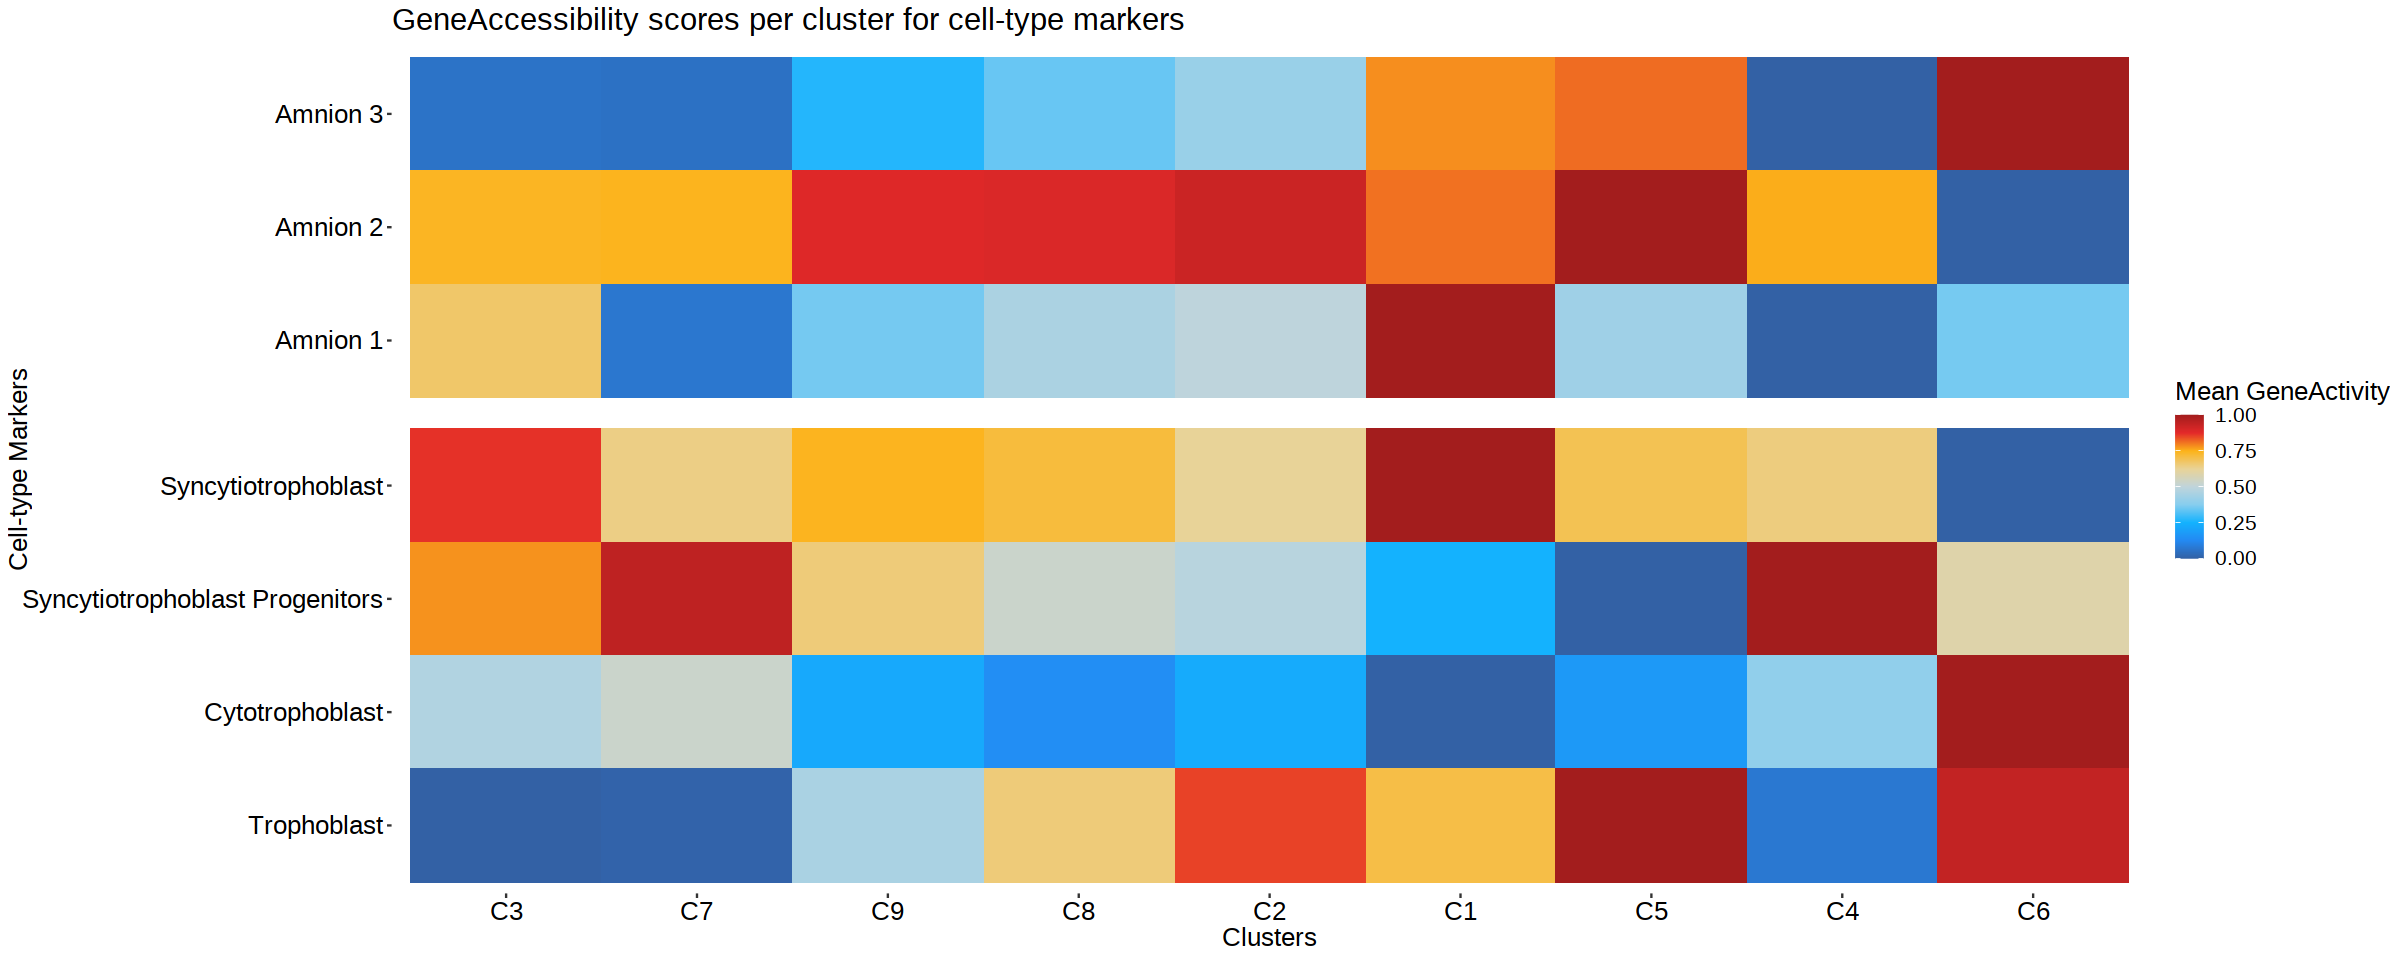

In [876]:

plot$broad = ifelse(plot$celltype %in% c('Trophoblast',                  
                  'Cytotrophoblast',
                  'Syncytiotrophoblast Progenitors',
                  'Syncytiotrophoblast'), 'Tropho', 'Amnion')

ggplot(plot, aes(factor(Clusters, levels = Cluster_levels), factor(celltype, levels = celltype_levels), fill=celltype_mean_minmax)) + 
        geom_tile() + 
        facet_grid(rows=vars(broad), scales ='free_y', space = "free") + 
        ylab('Cell-type Markers') +
        xlab('Clusters') + 
        ggtitle('GeneAccessibility scores per cluster for cell-type markers') + 
        scale_fill_gradientn(colors = paletteContinuous(), name='Mean GeneActivity') + 
        theme_classic() + theme(text = element_text(size = 15, colour='black'), 
                                axis.text.y = element_text(hjust=1, size = 15, colour='black'),
                                axis.text.x = element_text(size = 15, colour='black'),
                                axis.line.x = element_blank(),
                                axis.line.y = element_blank(),
                               strip.text.y = element_blank(),
                               strip.background = element_blank())

# Plot known markers - Motif

In [594]:
# Motif Matrix
Motif = getMatrixFromProject(
  ArchRProj = ArchRProject,
  useMatrix = "MotifMatrix")
gene_names = sapply(strsplit(Motif@elementMetadata$name,"_"), `[`, 1)
Motif = Motif@assays@data$z
rownames(Motif) = gene_names
keep = markers[marker %in% rownames(Motif)]$marker
imputed_motif = imputeMatrix(mat = as.matrix(Motif[row.names(Motif) %in% keep,]), 
                                     imputeWeights = getImputeWeights(ArchRProject))

Getting ImputeWeights



In [595]:
summary(colnames(imputed_motif) == rownames(ArchRProject))

   Mode   FALSE    TRUE 
logical    2502     259 

In [596]:
imputed_motif = imputed_motif[,match(rownames(ArchRProject), colnames(imputed_motif))]

In [597]:
summary(colnames(imputed_motif) == rownames(ArchRProject))

   Mode    TRUE 
logical    2761 

In [598]:
rownames(imputed_motif) = as.character(rownames(imputed_motif))

# minmax imputed count matrix
imputed_motif.minmax = apply(imputed_motif, 1, minmax) %>% t()

sce <- SingleCellExperiment(list(counts=imputed_motif.minmax))

colData(sce) = ArchRProject@cellColData
sce_pseudobulk <- aggregateAcrossCells(sce, id=sce$Clusters, statistics = 'mean', BPPARAM = BPPARAM)

In [599]:
counts_pseudobulk = counts(sce_pseudobulk)

In [600]:
counts.mod = counts_pseudobulk

In [601]:
plot = as.data.table(t(counts.mod), keep.rownames=T) %>% 
        setnames('rn', 'Clusters') %>%
        melt(id.vars =  'Clusters') %>%
        unique(by=c('variable', 'value', 'Clusters')) %>% 
        merge(.,markers,  by.x='variable', by.y='marker') %>% 
        setnames('variable', 'gene')

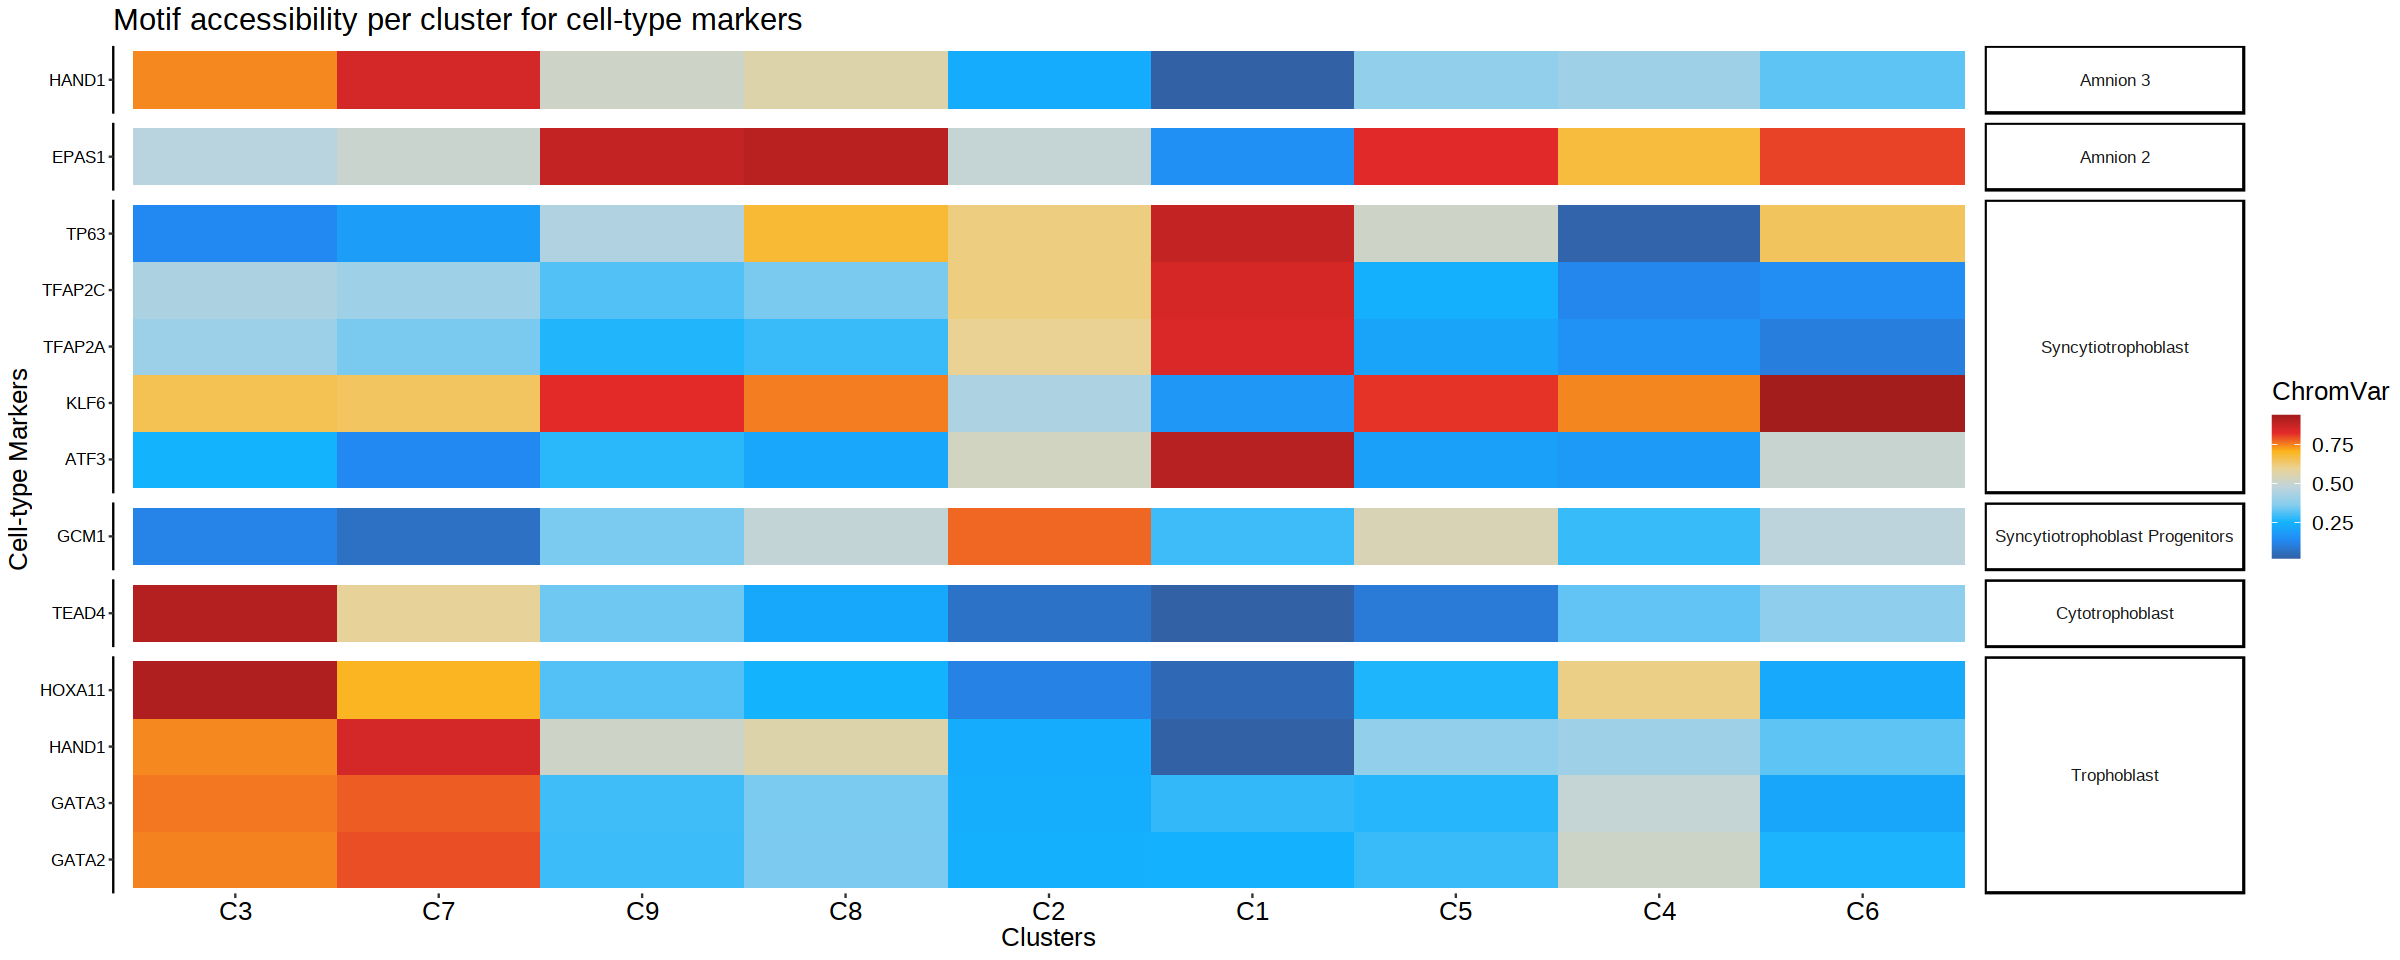

In [602]:
ggplot(plot, aes(factor(Clusters, levels = Cluster_levels), gene, fill=value)) +  # factor(gene, levels=unique(markers$marker))
        geom_tile() + 
        facet_grid(factor(celltype, levels = rev(celltype_levels))~., scales ='free_y', space = "free") + 
        ylab('Cell-type Markers') +
        xlab('Clusters') + 
        ggtitle('Motif accessibility per cluster for cell-type markers') + 
        scale_fill_gradientn(colors = paletteContinuous(), name='ChromVar') + 
        theme_classic() + theme(text = element_text(size = 15, colour='black'), 
                                axis.text.y = element_text(hjust=1, size = 10, colour='black'),
                                axis.text.x = element_text(size = 15, colour='black'),
                                axis.line.x = element_blank(),
                               strip.text.y = element_text(angle = 0, size=10))

# Trophoblast annotation

In [4]:
library(SingleCellExperiment)
library(scuttle)

BPPARAM <- BiocParallel::bpparam()
BPPARAM$workers = 16

In [4]:
annotation = data.table(Clusters = paste0('C', 1:9),
                       Tropho_celltype = c('Syncytiotrophoblast', #1
                                           'Syncytiotrophoblast Progenitors', #2
                                           'Trophoblast', #3
                                           'Amnion', #4
                                           'Amnion', #5 # Tac4, SNX10, PGF
                                           'Amnion', #6 
                                           'Trophoblast', #7
                                           'Cytotrophoblast', #8
                                           'Cytotrophoblast' #9 label transfer = amnion 2, but is very similar to cytotropho
                                          ))

annotation = annotation %>% .[match(ArchRProject@cellColData$Clusters, annotation$Clusters),]
ArchRProject@cellColData$celltype_tropho = annotation$Tropho_celltype

trajectory <- c('Trophoblast', 
                'Cytotrophoblast', 
                'Syncytiotrophoblast Progenitors',
                'Syncytiotrophoblast'
                )

celltype_tropho_levels = c('Trophoblast', 
                            'Cytotrophoblast', 
                            'Syncytiotrophoblast Progenitors',
                            'Syncytiotrophoblast', 
                           'Amnion')

In [20]:
#### Get whole dataset matrix
# Run imputation
markers_matrix.imputed = imputeMatrix(mat = as.matrix(genescores), 
                             imputeWeights = getImputeWeights(ArchRProject))

summary(colnames(markers_matrix.imputed) == rownames(ArchRProject))
markers_matrix.imputed = markers_matrix.imputed[,match(rownames(ArchRProject), colnames(markers_matrix.imputed))]
summary(colnames(markers_matrix.imputed) == rownames(ArchRProject))


rownames(markers_matrix.imputed) = as.character(rownames(markers_matrix.imputed))
sce <- SingleCellExperiment(list(counts=markers_matrix.imputed))

# minmax imputed count matrix
#markers_matrix.imputed.minmax = apply(markers_matrix.imputed, 1, minmax) %>% t()
#sce <- SingleCellExperiment(list(counts=markers_matrix.imputed.minmax))


colData(sce) = ArchRProject@cellColData
sce_pseudobulk <- aggregateAcrossCells(sce, id=sce$celltype_tropho, statistics = 'mean', BPPARAM = BPPARAM)

Getting ImputeWeights



   Mode   FALSE    TRUE 
logical    2502     259 

   Mode    TRUE 
logical    2761 

In [21]:
counts.mod = counts(sce_pseudobulk)
# Minmax normalisation after pseudobulking
counts.mod = apply(counts.mod, 1, minmax) %>% t()


In [22]:
plot = as.data.table(t(counts.mod), keep.rownames=T) %>% 
        setnames('rn', 'celltype_tropho') %>%
        melt(id.vars =  'celltype_tropho') %>%
        unique(by=c('variable', 'value', 'celltype_tropho')) %>%
        setnames('variable', 'gene')

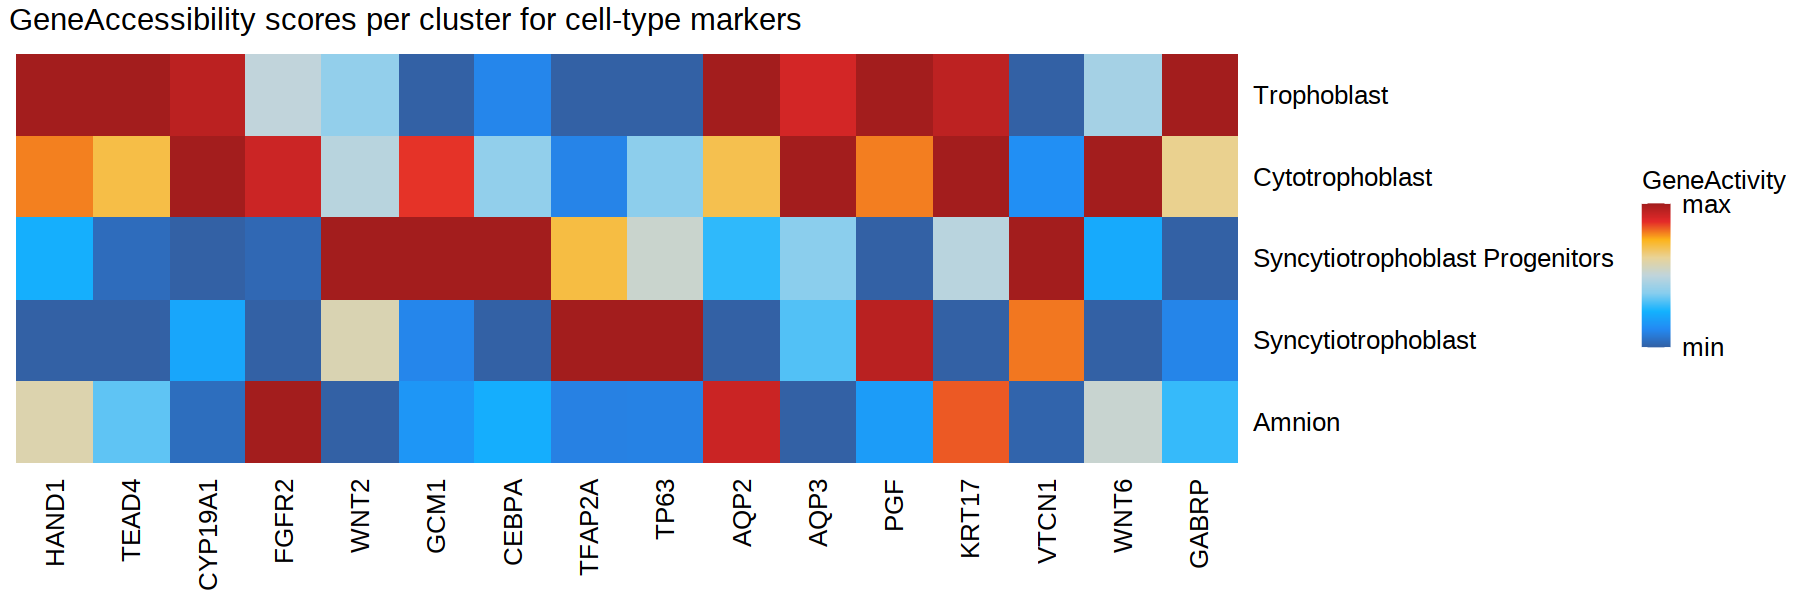

In [23]:
markers_Dan = c('HAND1', 
                'TEAD4',
                'CYP19A1', 
                'FGFR2', 
                'WNT2', 
                'GCM1', 
                'CEBPA',
                'TFAP2A', 
                'TFAP2C', 
                'TP63', 
                'CDX2', 
                'AQP2', 
                'AQP3', 
                'PGF', 
                'KRT17', 
                'VTCN1', 
                'WNT6', 
                'GABRP', 
                'ISL')

ggplot(plot[gene %in% markers_Dan], aes(factor(gene, levels=markers_Dan), 
                                        factor(celltype_tropho, levels = rev(celltype_tropho_levels)), 
                                        fill=value)) +  # factor(gene, levels=unique(markers$marker))
        geom_tile() + 
      #  facet_grid(factor(celltype, levels = rev(celltype_levels))~., scales ='free_y', space = "free") + 
        ylab('Cell-type Markers') + xlab('Marker') +
        ggtitle('GeneAccessibility scores per cluster for cell-type markers') + 
        scale_fill_gradientn(colors = paletteContinuous(), name='GeneActivity', breaks = c(0, 1), labels = c("min", "max")) +
#scale_color_continuous(breaks = c(0, 100), labels = c("min", "max"))
        scale_y_discrete(position = "right") +
        theme_classic() + theme(text = element_text(size = 15, colour='black'), 
                                axis.text.y = element_text(hjust=1, size = 15, colour='black'),
                                axis.text.x = element_text(size = 15, colour='black', angle=90, hjust=1, vjust=0.5),
                                axis.line.x = element_blank(),
                                axis.line.y = element_blank(),
                                axis.ticks = element_blank(), 
                                axis.title = element_blank(), 
                                strip.text.y = element_text(angle = 0, size=10),
                                legend.text = element_text(size=15))

In [24]:
sce_pseudobulk$celltype_tropho 

[1] "Amnion"                          "Cytotrophoblast"                
[3] "Syncytiotrophoblast"             "Syncytiotrophoblast Progenitors"
[5] "Trophoblast"

In [31]:
# Remove Amnion for final plot

counts.mod = counts(sce_pseudobulk[, sce_pseudobulk$celltype_tropho != 'Amnion'])
# Minmax normalisation after pseudobulking
counts.mod = apply(counts.mod, 1, minmax) %>% t()


In [32]:
plot = as.data.table(t(counts.mod), keep.rownames=T) %>% 
        setnames('rn', 'celltype_tropho') %>%
        melt(id.vars =  'celltype_tropho') %>%
        unique(by=c('variable', 'value', 'celltype_tropho')) %>%
        setnames('variable', 'gene') %>%
        .[, celltype_tropho:= gsub('Syncytiotrophoblast',  'SCT', celltype_tropho)]

In [33]:
celltype_tropho_levels = gsub('Syncytiotrophoblast',  'SCT', celltype_tropho_levels)

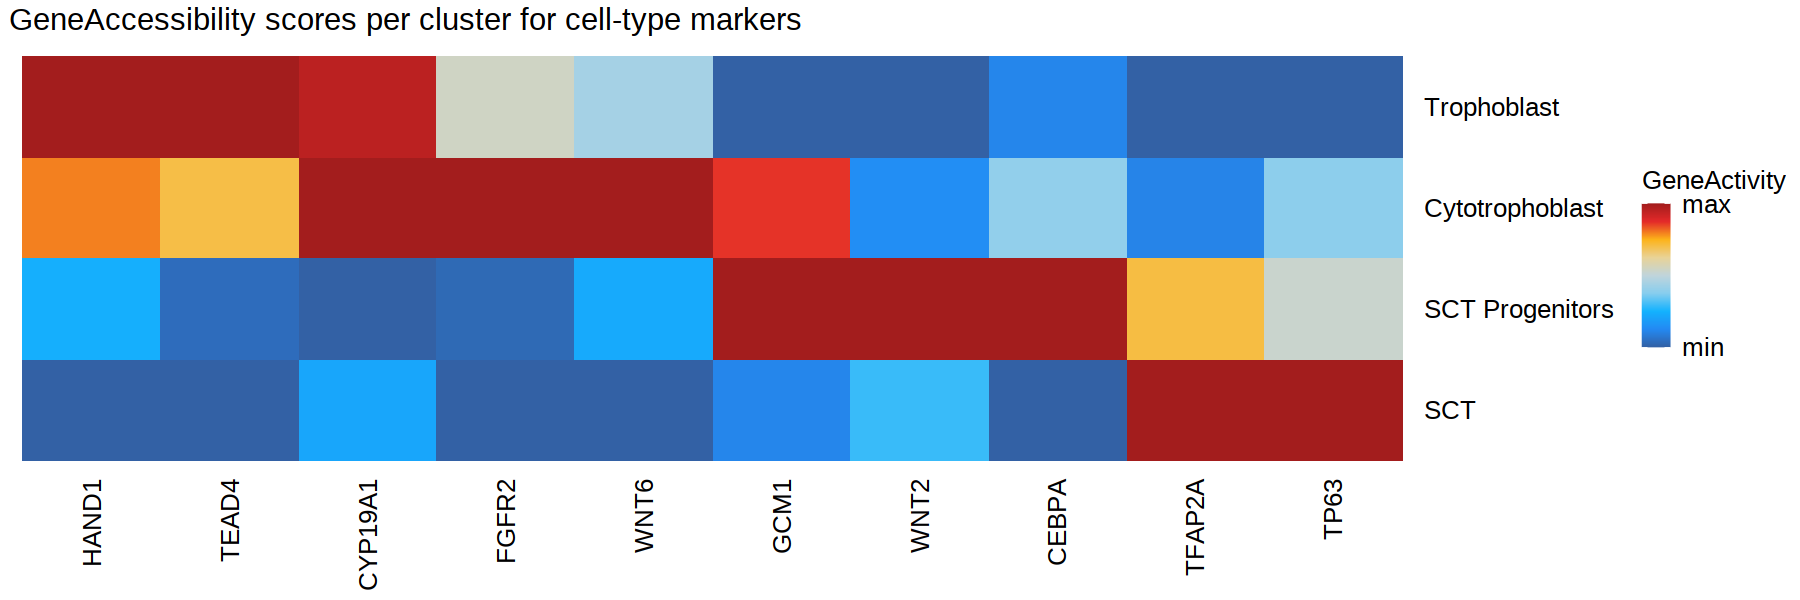

In [34]:
markers_Dan = c('HAND1', 
                'TEAD4',
                'CYP19A1', 
                'FGFR2',
                'WNT6',
                'GCM1', 
                'WNT2', 
                'CEBPA',
                'TFAP2A', 
                'TFAP2C', 
                'TP63')

p = ggplot(plot[gene %in% markers_Dan], aes(factor(gene, levels=markers_Dan), 
                                        factor(celltype_tropho, levels = rev(celltype_tropho_levels)), 
                                        fill=value)) +  # factor(gene, levels=unique(markers$marker))
        geom_tile() + 
      #  facet_grid(factor(celltype, levels = rev(celltype_levels))~., scales ='free_y', space = "free") + 
        ylab('Cell-type Markers') + xlab('Marker') +
        ggtitle('GeneAccessibility scores per cluster for cell-type markers') + 
        scale_fill_gradientn(colors = paletteContinuous(), name='GeneActivity', breaks = c(0, 1), labels = c("min", "max")) +
        scale_y_discrete(position = "right") +
        theme_classic() + theme(text = element_text(size = 15, colour='black'), 
                                axis.text.y = element_text(hjust=1, size = 15, colour='black'),
                                axis.text.x = element_text(size = 15, colour='black', angle=90, hjust=1, vjust=0.5),
                                axis.line.x = element_blank(),
                                axis.line.y = element_blank(),
                                axis.ticks = element_blank(), 
                                axis.title = element_blank(), 
                                strip.text.y = element_text(angle = 0, size=10),
                                legend.text = element_text(size=15))
p

In [35]:
pdf(sprintf('%s/tropho_markers_accessibility.pdf', io$plot.trophoblast), width=10, height=5, onefile=T)
    p
dev.off()

png 
  2

### Motif enrichment

In [94]:
plot_enr_heatmap = function(enrichMotifs, ntop=25, TF_family=TRUE, TF_keep=c(NULL)) {
    heatmapEM <- plotEnrichHeatmap(enrichMotifs, n = ntop, returnMatrix = TRUE)
    celltype_tropho_levels = gsub('Syncytiotrophoblast',  'SCT', celltype_tropho_levels)
    
    enriched.dt = melt(as.data.table(heatmapEM, keep.rownames=T) %>% setnames('rn', 'TF'), id.vars = c("TF")) %>%
        .[order(-value)] 
    keep_tfs = enriched.dt[, head(.SD, ntop),  by=variable]$TF
    enriched.dt = enriched.dt[TF %in% keep_tfs] %>% .[order( -value)] %>% 
        .[,TF:=strsplit(TF, '_') %>% map_chr(1)] %>%
        .[,TF_family:=sub("[0-9].*$", "", TF)] %>%
        .[,TF_family:=ifelse(TF_family=='TFAP', TF, TF_family)] %>% # restory TFAP bc TFAP2D behaves different
        .[,TF_family:=ifelse(TF_family=='E', 'E2F', TF_family)] %>% # E2F cut off too short
        .[, variable:= gsub('Syncytiotrophoblast',  'SCT', variable)] %>%
         .[,variable:=factor(variable, levels=rev(celltype_tropho_levels))] %>%
         .[order(-value, variable, TF_family)] %>% 
         .[,TF:=factor(TF, levels=rev(unique(TF)))]
    
    if(!is.null(TF_keep)){
        enriched.dt = enriched.dt[TF %in% TF_keep]
    }
    
    p = ggplot(enriched.dt, aes(TF, variable, fill=value)) + 
    geom_tile(col='black') + 
    scale_fill_gradient2(low='grey80', high='darkblue', name='Norm. Enrichment -log10(P-adj) [0-max]', position='bottom') + 
    scale_y_discrete(position = "right") +
    guides(fill = guide_legend(title.position = "top")) +
    theme_classic() + theme(text = element_text(size = 15, colour='black'), 
                            axis.text.y = element_text(hjust=1, size = 15, colour='black'),
                            axis.text.x = element_text(size = 15, colour='black', angle=90, hjust=1, vjust=0.5),
                            axis.line.x = element_blank(),
                            axis.line.y = element_blank(),
                            axis.ticks = element_blank(), 
                            axis.title = element_blank(), 
                            strip.text.y = element_text(angle = 0, size=10),
                            legend.text = element_text(size=15),
                            legend.position='bottom')

    if(TF_family==TRUE){
    enriched.dt = enriched.dt %>%
        unique(by=c('TF_family', 'variable')) %>% 
         .[,TF_family:=factor(TF_family, levels=unique(TF_family))]
        
    p = ggplot(enriched.dt, aes(TF_family, variable, fill=value)) + 
        geom_tile(col='black') + 
        #viridis::scale_fill_viridis(name='Norm. Enrichment -log10(P-adj) [0-max]') + 
        scale_fill_gradient2(low='grey80', high='darkblue', name='Norm. Enrichment -log10(P-adj) [0-max]') + 
        scale_y_discrete(position = "right") +
        theme_classic() + theme(text = element_text(size = 15, colour='black'), 
                            axis.text.y = element_text(hjust=1, size = 15, colour='black'),
                            axis.text.x = element_text(size = 15, colour='black', angle=90, hjust=1, vjust=0.5),
                            axis.line.x = element_blank(),
                            axis.line.y = element_blank(),
                            axis.ticks = element_blank(), 
                            axis.title = element_blank(), 
                            strip.text.y = element_text(angle = 0, size=10),
                            legend.text = element_text(size=15),
                               legend.position='bottom')
        
    }


    return(p)
}

In [7]:
subset = ArchRProject[ArchRProject$celltype_tropho!='Amnion',]

Dropping ImputeWeights Since You Are Subsetting Cells! ImputeWeights is a cell-x-cell Matrix!



In [8]:
addArchRThreads(1)

Setting default number of Parallel threads to 1.



In [11]:
markersPeaks <- getMarkerFeatures(
    ArchRProj = ArchRProject, 
    useMatrix = "PeakMatrix", 
    groupBy = "celltype_tropho",
  bias = c("TSSEnrichment", "log10(nFrags)"),
  testMethod = "wilcoxon",
    verbose=T
)

In [12]:
markersPeaks

class: SummarizedExperiment 
dim: 332773 5 
metadata(2): MatchInfo Params
assays(7): Log2FC Mean ... AUC MeanBGD
rownames(332773): 1 2 ... 332772 332773
rowData names(4): seqnames idx start end
colnames(5): Amnion Cytotrophoblast Syncytiotrophoblast
  Syncytiotrophoblast Progenitors Trophoblast
colData names(0):

In [13]:
colnames(markersPeaks) = gsub('Syncytiotrophoblast',  'SCT', colnames(markersPeaks))

In [14]:
markersPeaks = markersPeaks[,colnames(markersPeaks) != 'Amnion']

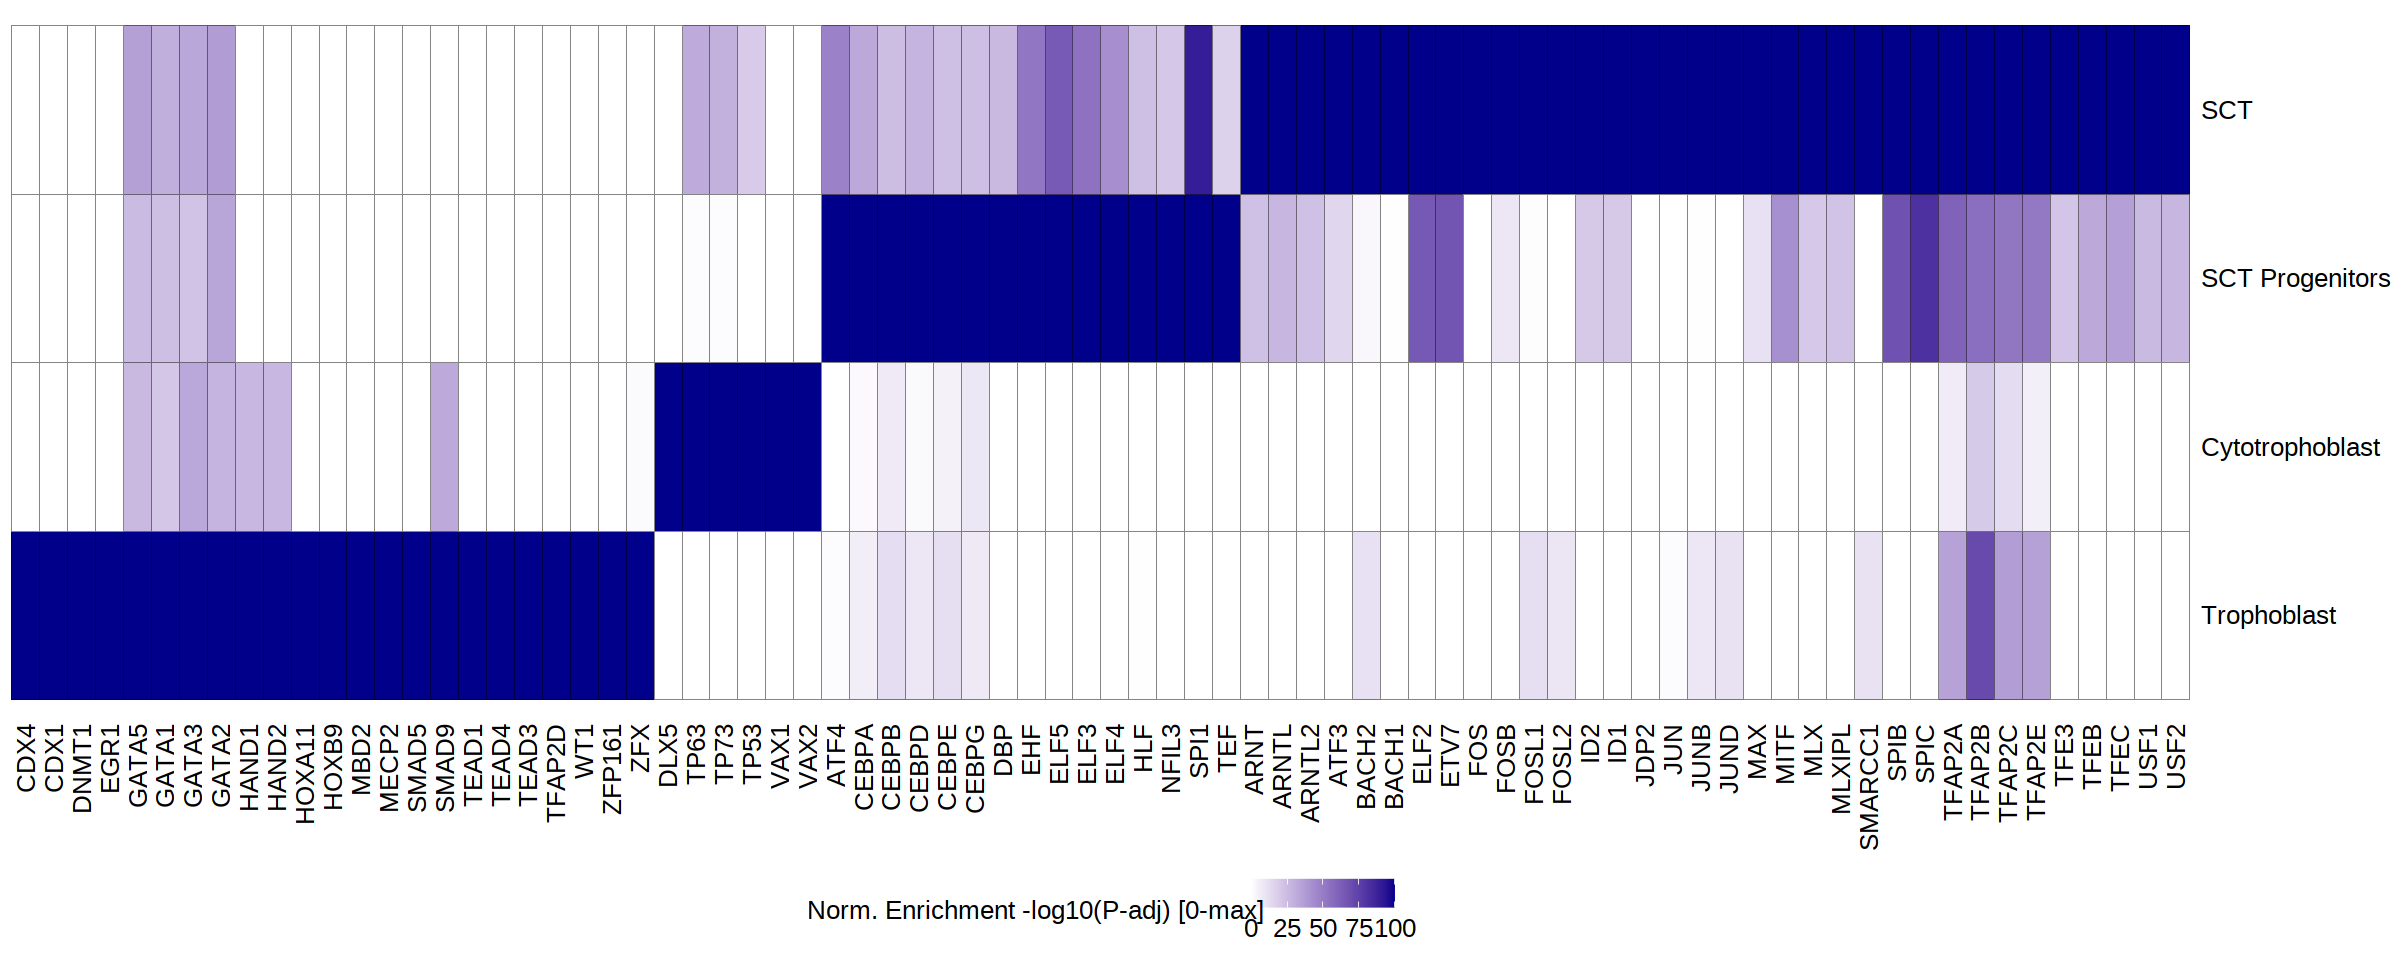

In [70]:
motifs <- peakAnnoEnrichment(
    seMarker = markersPeaks,
    ArchRProj = subset,
    peakAnnotation = "Motif",
    cutOff = "FDR <= 0.05 & Log2FC >= 0.5"
  )
options(repr.plot.width=20, repr.plot.height=8)
p = plot_enr_heatmap(motifs, ntop = 1000, TF_family=F)
p

In [88]:
pdf(sprintf('%s/tropho_peak_enrichment.pdf', io$plot.trophoblast), width=18, height=6, onefile=T)
    plot_enr_heatmap(motifs, ntop = 1000, TF_family=F)
dev.off()

png 
  2

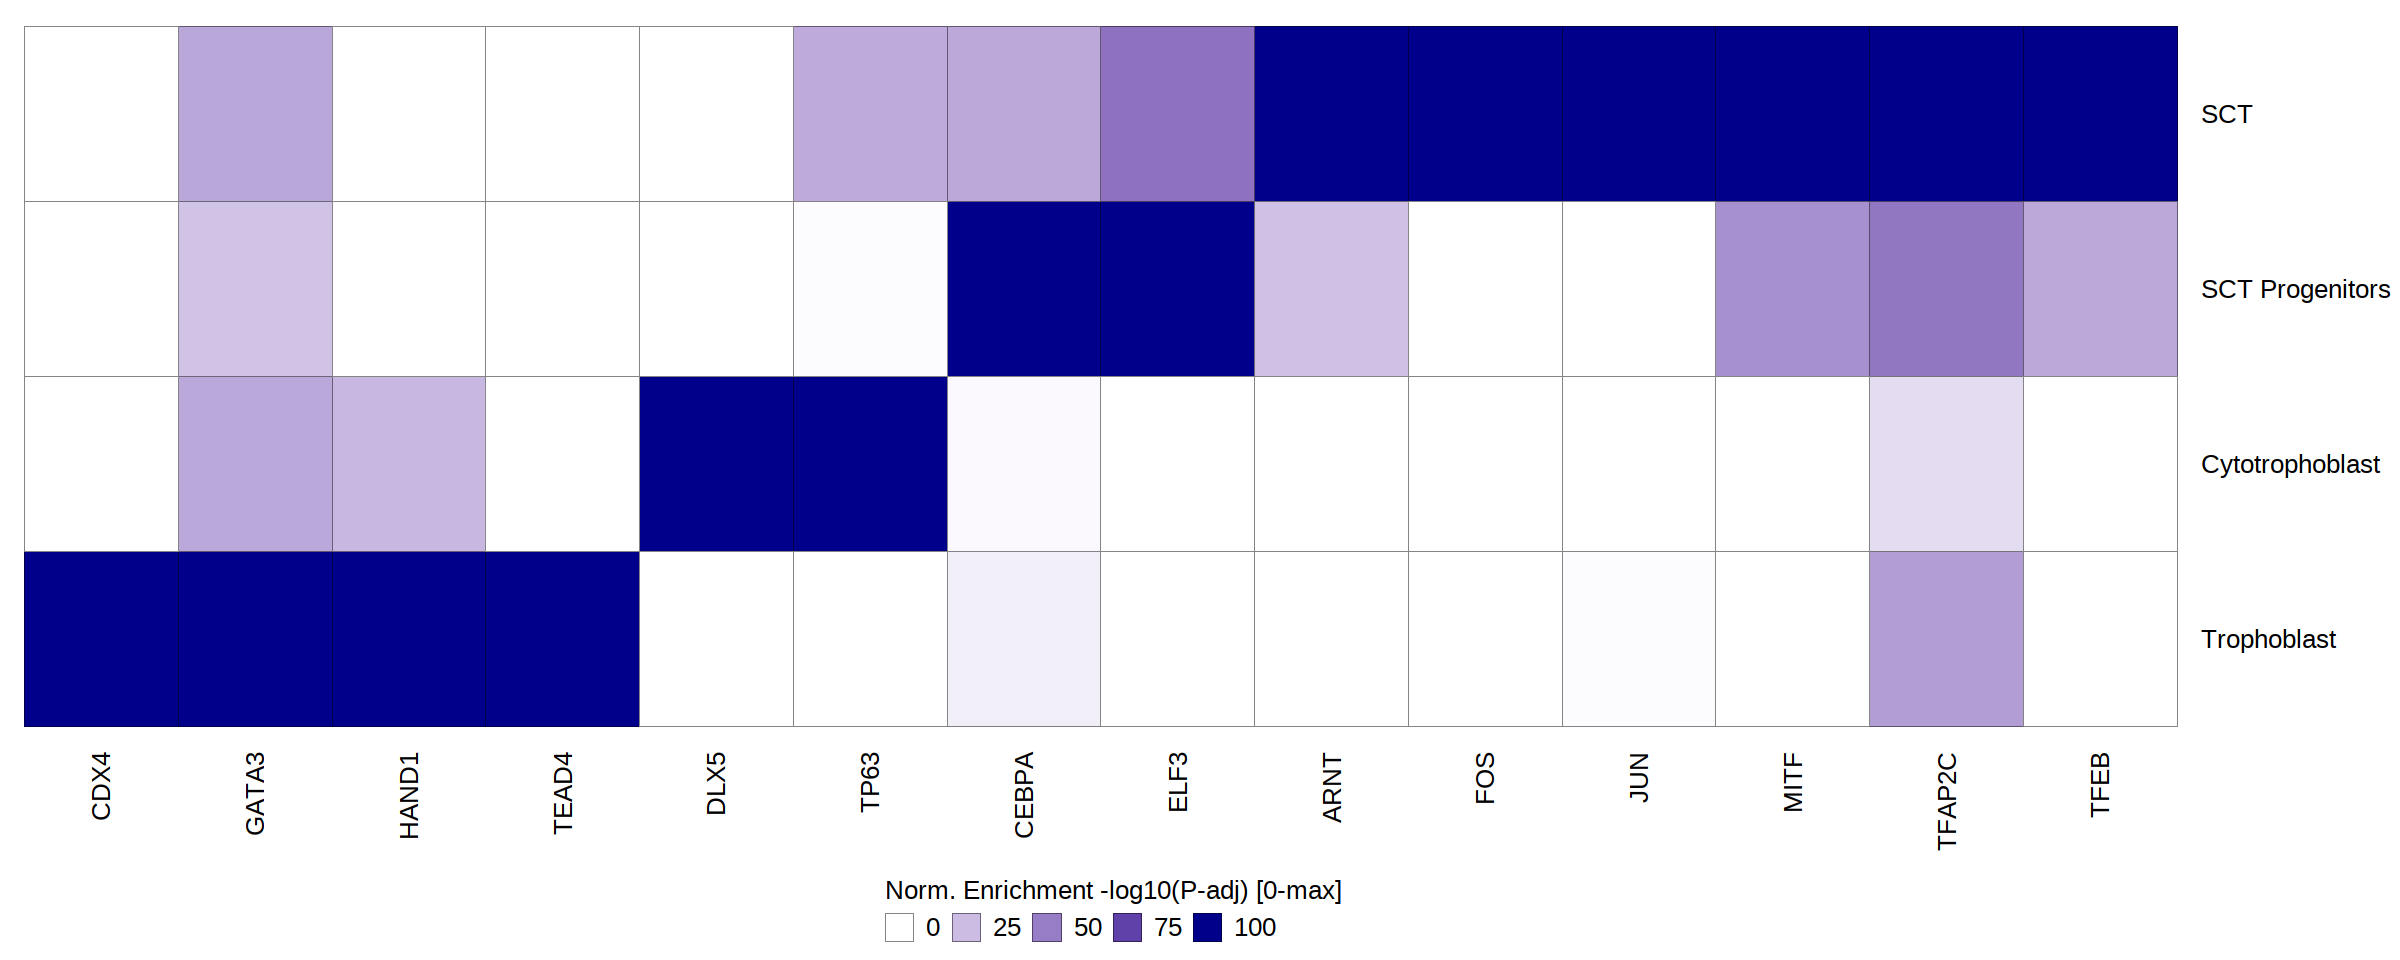

In [89]:
TFs_to_keep = c('CDX4', 'GATA3', 'HAND1', 'TEAD4',
                'DLX5', 'TP63', 
                'CEBPA', 'ELF3', 
                'TFAP2C', 'MITF', 'TFEB', 'FOS', 'JUN', 'ARNT')
p = plot_enr_heatmap(motifs, ntop = 1000, TF_family=F, TF_keep=TFs_to_keep)
p

In [96]:
pdf(sprintf('%s/tropho_peak_enrichment_selected_TFs.pdf', io$plot.trophoblast), width=10, height=5, onefile=T)
    plot_enr_heatmap(motifs, ntop = 1000, TF_family=F, TF_keep=TFs_to_keep)
dev.off()

png 
  2

# QC plots specific for trophoblast

In [7]:
meta = as.data.table(ArchRProject@cellColData)

In [15]:
QC_plot = meta %>% 
    .[,c('Sample', 'TSSEnrichment', 'nFrags', 'FRIP', 'stage', 'celltype_tropho')] %>%
    melt(id.vars = c('Sample', 'stage', 'celltype_tropho'), variable.name='statistic', value.name='value') %>%
    .[,Sample:=gsub('rabbit_', '', Sample)]

In [21]:
opts$trophoblast_colours = opts$celltype_colours[names(opts$celltype_colours) %in%  unique(meta$celltype_tropho)]

In [23]:
opts$trophoblast_colours

Amnion                     Trophoblast 
                      "#549E79"                       "#989898" 
                Cytotrophoblast Syncytiotrophoblast Progenitors 
                      "#46c5bf"                       "#7766db" 
            Syncytiotrophoblast 
                      "#7295e2"

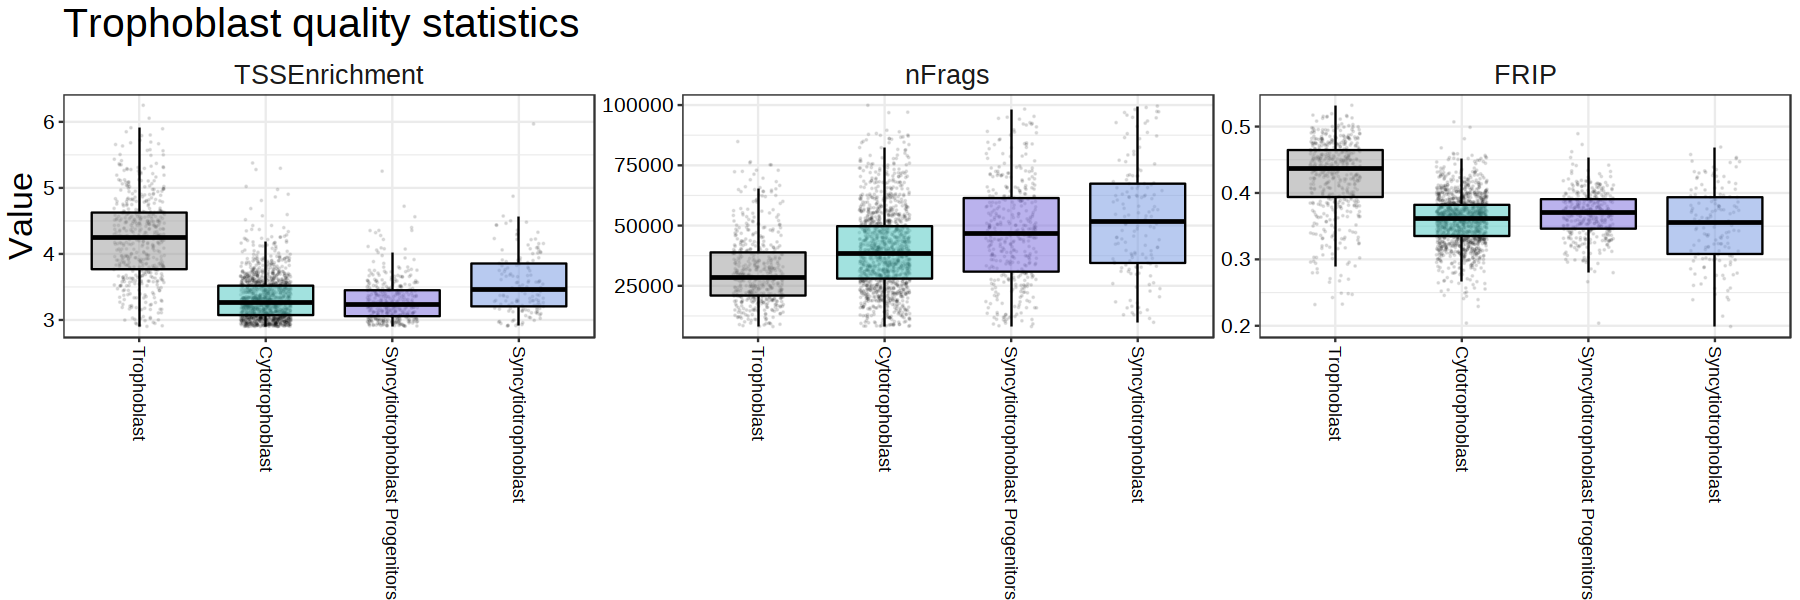

In [30]:
p = ggplot(QC_plot[celltype_tropho!='Amnion'], aes(factor(celltype_tropho, levels = celltype_tropho_levels), value)) + 
    geom_point(size=0.05, alpha=0.1, position=position_jitter(width = 0.2)) + 
    geom_boxplot(outlier.shape=NA, alpha=0.5, aes(fill=celltype_tropho), col='black') +
    scale_fill_manual(values=opts$trophoblast_colours) + 
    facet_wrap(~statistic, scales='free') +
    #ylim(0, NA) + 
    ylab('Value') + 
    ggtitle('Trophoblast quality statistics') + 
    theme_bw() +
    theme(
            legend.position = "none",
            legend.title = element_blank(),
            axis.text.x = element_text(colour="black",size=rel(0.65), angle=-90, hjust=0, vjust=0.5),  
            axis.text.y = element_text(colour="black",size=rel(0.75)),  
            axis.title.x = element_blank(),
            text=element_text(size=20, colour='black'),
            strip.background=element_blank()
        ) 
p 

In [33]:
pdf(sprintf("%s/trophoblast_quality_statistics.pdf",io$plot.trophoblast), width=9, height=5)
    p
dev.off()

png 
  2